#Import Library

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
sns.set()
%matplotlib inline
sns.set()
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import cosine_similarity
import missingno as msno
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

#Read Data

In [4]:
df_vif_clean = pd.read_csv('df_vif_clean.csv')

df_vif_clean.head()

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,type of travel_Personal Travel,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium
0,460,5,4,3,4,18.0,3.0,1,1,1,1,0,0,0,1,1,0
1,235,1,1,5,1,6.0,3.0,2,1,0,0,0,0,0,0,1,0
2,1142,5,4,3,4,0.0,3.5,2,0,1,0,1,1,0,0,0,0
3,562,2,2,5,1,9.0,3.5,2,0,1,0,0,0,0,0,1,0
4,214,4,3,4,3,0.0,4.0,2,1,1,0,1,0,1,0,0,0


In [5]:
# df_vif_clean = pd.read_excel('https://raw.github.com/nadiraaini77/python-data-analyst/master/df_vif_clean.xlsx')

#Scaling

In [6]:
rs = RobustScaler()
x_scaled = pd.DataFrame(rs.fit_transform(df_vif_clean), columns = rs.feature_names_in_)
x_scaled

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,type of travel_Personal Travel,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium
0,-0.284314,1.0,0.0,-0.5,1.0,1.384615,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,-0.453997,-1.0,-1.5,0.5,-2.0,0.461538,0.00,0.5,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.230015,1.0,0.0,-0.5,1.0,0.000000,0.25,0.5,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,-0.207391,-0.5,-1.0,0.5,-2.0,0.692308,0.25,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.469834,0.5,-0.5,0.0,0.0,0.000000,0.50,0.5,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66974,-0.309201,0.0,0.0,0.5,0.0,0.000000,0.25,0.5,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
66975,0.006787,1.0,-1.5,-1.5,1.0,0.000000,-0.50,-0.5,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
66976,-0.383861,0.5,-0.5,-0.5,-2.0,0.000000,0.50,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
66977,-0.400452,0.0,0.5,0.5,1.0,0.692308,0.75,0.5,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


#PCA

In [7]:
pca = PCA()
pca.fit(x_scaled)
pca.explained_variance_ratio_

array([0.60734041, 0.11667902, 0.05734909, 0.03304916, 0.03072753,
       0.02226108, 0.02054983, 0.01830388, 0.01695271, 0.01650587,
       0.01584561, 0.01200027, 0.00962873, 0.0077525 , 0.00664761,
       0.00488884, 0.00351786])

Text(0, 0.5, 'Cumulative Explained Variance')

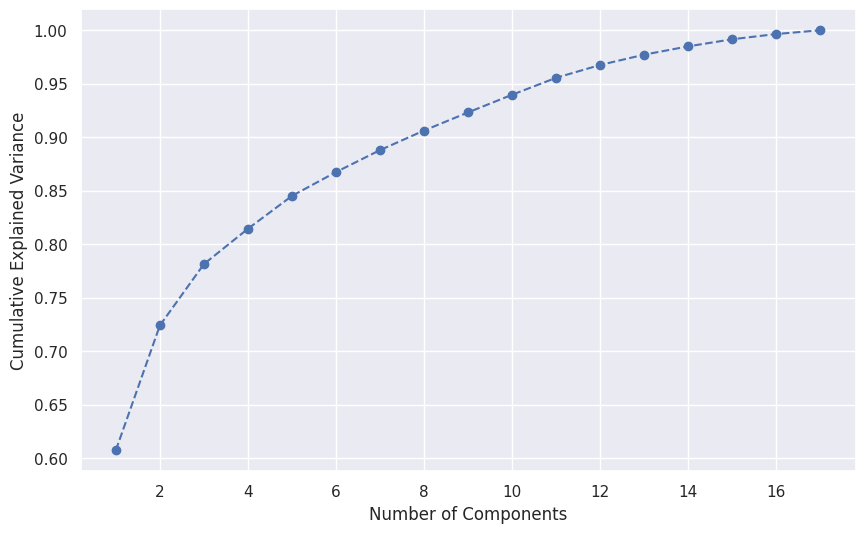

In [8]:
plt.figure(figsize=(10,6))
plt.plot(range(1,18), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--') #18 didapat dari 17 kolom + 1
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [9]:
pca = PCA(n_components=4)
pca.fit(x_scaled)
df_pca_components = pd.DataFrame(
    data=pca.components_.round(4),
    columns=x_scaled.columns.values,
    index={'component'+str(i+1): i for i in range(4)})
df_pca_components

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,type of travel_Personal Travel,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium
component1,0.0002,-0.0070,-0.0083,0.0022,-0.0097,0.9991,-0.0036,-0.0018,0.0011,-0.0005,-0.0012,-0.0094,-0.0005,-0.0019,0.0006,-0.0227,0.0314
component2,0.1177,0.0770,0.1867,0.1456,0.9360,0.0129,0.1036,0.1075,0.0068,0.0245,-0.0294,0.1478,0.0295,0.0272,-0.0251,-0.0012,-0.0025
component3,0.6091,0.1461,0.2091,0.2841,-0.3107,0.0037,0.2548,0.3345,0.0073,0.0911,-0.2608,0.3138,0.1363,0.0744,-0.1044,0.0028,-0.0054
component4,-0.5356,0.0733,0.5329,0.5925,-0.1453,0.0026,0.0529,-0.0717,0.0184,-0.0577,0.0224,0.1179,-0.1533,-0.0198,0.0243,-0.0340,-0.0016


In [10]:
# plt.figure(figsize=(20,20))
# s = sns.heatmap(df_pca_components,
#     vmin=-1,
#     vmax=1,
#     cmap='RdBu',
#     annot=True)
# plt.title('Correlation Matrix')
# plt.show()

In [11]:
pca_scores = pca.transform(x_scaled)
results = {}
for i in range(1, 5): #5 didapat dari 4 + 1
  kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans_pca.fit(pca_scores)
  results[i] = kmeans_pca.inertia_

#Elbow Method

In [12]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(pca_scores)

    wcss.append(kmeans.inertia_)

In [13]:
wcss

[802674.3035412689,
 433739.494973632,
 331478.9590365454,
 282812.67590828676,
 214874.014920251,
 192121.00476412856,
 164155.99279551557,
 151567.55287997762,
 136620.0826954205,
 127699.16713822758]

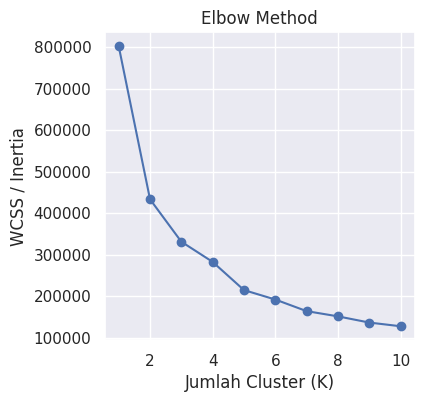

In [14]:
plt.figure(figsize=(4,4))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS / Inertia')

plt.show()

#Silhouette

In [15]:
# import pandas as pd
# from sklearn.cluster import KMeans
# from sklearn.metrics import silhouette_score
# import matplotlib.pyplot as plt

# silhouette_avg = []
# K_range = range(2, 6)

# for k in K_range:
#     kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
#     cluster_labels = kmeans.fit_predict(pca_scores)
#     score = silhouette_score(pca_scores, cluster_labels)
#     silhouette_avg.append(score)
#     print(f"Jumlah Cluster (k) = {k} | Silhouette Score = {score:.4f}")

# plt.figure(figsize=(7, 4))
# plt.plot(K_range, silhouette_avg, marker='o', color='orange', linestyle='-')
# plt.title('Silhouette Method untuk Konfirmasi K Optimal')
# plt.xlabel('Jumlah Cluster (k)')
# plt.ylabel('Silhouette Score')
# plt.grid(True)
# plt.show()

#K-Means

In [16]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

labels_kmeans = kmeans.fit_predict(pca_scores)

In [17]:
kmeans_pca = KMeans(n_clusters=4,random_state=42)
kmeans_pca.fit(pca_scores)

KMeans(n_clusters=4, random_state=42)

In [18]:
df_segm_pca = pd.concat([df_vif_clean.reset_index(drop=True),pd.DataFrame(pca_scores,columns=['component 1','component 2','component 3','component 4'])],axis=1)
df_segm_pca['Cluster'] = kmeans_pca.labels_
df_segm_pca.head()

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,...,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium,component 1,component 2,component 3,component 4,Cluster
0,460,5,4,3,4,18.0,3.0,1,1,1,...,0,0,1,1,0,0.185811,0.570773,-0.851258,0.335379,0
1,235,1,1,5,1,6.0,3.0,2,1,0,...,0,0,0,1,0,-0.678594,-2.473752,0.093633,0.481504,0
2,1142,5,4,3,4,0.0,3.5,2,0,1,...,1,0,0,0,0,-1.187109,0.919424,0.492919,-0.032778,0
3,562,2,2,5,1,9.0,3.5,2,0,1,...,0,0,0,1,0,-0.458061,-2.266214,0.569808,0.590190,0
4,214,4,3,4,3,0.0,4.0,2,1,1,...,0,1,0,0,0,-1.169998,-0.127622,0.350866,0.645671,0


In [19]:
#lihat jumlah anggota cluster
df_segm_pca['Cluster'].value_counts()

,count
Cluster,
0,56412
1,8085
2,2171
3,311


In [20]:
df_segm_pca['Cluster'].value_counts(normalize=True)*100

,proportion
Cluster,
0,84.223413
1,12.070948
2,3.241314
3,0.464325


In [21]:
#profiling
cluster_profile = (
    df_segm_pca
    .groupby('Cluster')
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,...,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium,component 1,component 2,component 3,component 4
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1190.14,3.22,3.41,3.35,3.33,3.45,3.01,1.04,0.49,0.82,...,0.45,0.29,0.37,0.19,0.45,0.00,-0.91,0.01,0.01,0.00
1,1156.21,3.12,3.27,3.26,3.20,50.13,2.93,0.98,0.50,0.81,...,0.34,0.28,0.36,0.19,0.20,0.76,2.71,-0.11,-0.06,-0.03
2,1188.94,3.07,3.25,3.48,3.20,143.90,2.95,1.01,0.49,0.82,...,0.37,0.28,0.35,0.19,0.00,0.05,9.90,0.01,0.03,0.04
3,1322.53,3.08,3.17,3.63,3.38,345.80,3.04,1.03,0.53,0.80,...,0.41,0.33,0.30,0.23,0.00,0.00,25.41,0.41,0.15,0.03


In [22]:
df_segm_pca.rename(columns={
    "Cluster": "Segment", #ganti nama kolom
}, inplace=True)
df_segm_pca["Segment"].replace({
    0: "Loyal Satisfied Passenger",
    1: "Severely Delayed Passenger",
    2: "Digitally Frustrated Passenger",
    3: "Delay Sensitive Passenger"
}, inplace=True)
df_segm_pca.head()

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,...,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium,component 1,component 2,component 3,component 4,Segment
0,460,5,4,3,4,18.0,3.0,1,1,1,...,0,0,1,1,0,0.185811,0.570773,-0.851258,0.335379,Loyal Satisfied Passenger
1,235,1,1,5,1,6.0,3.0,2,1,0,...,0,0,0,1,0,-0.678594,-2.473752,0.093633,0.481504,Loyal Satisfied Passenger
2,1142,5,4,3,4,0.0,3.5,2,0,1,...,1,0,0,0,0,-1.187109,0.919424,0.492919,-0.032778,Loyal Satisfied Passenger
3,562,2,2,5,1,9.0,3.5,2,0,1,...,0,0,0,1,0,-0.458061,-2.266214,0.569808,0.590190,Loyal Satisfied Passenger
4,214,4,3,4,3,0.0,4.0,2,1,1,...,0,1,0,0,0,-1.169998,-0.127622,0.350866,0.645671,Loyal Satisfied Passenger


In [23]:
#jumlah anggota tiap segment
df_segm_pca['Segment'].value_counts()

,count
Segment,
Loyal Satisfied Passenger,56412
Severely Delayed Passenger,8085
Digitally Frustrated Passenger,2171
Delay Sensitive Passenger,311


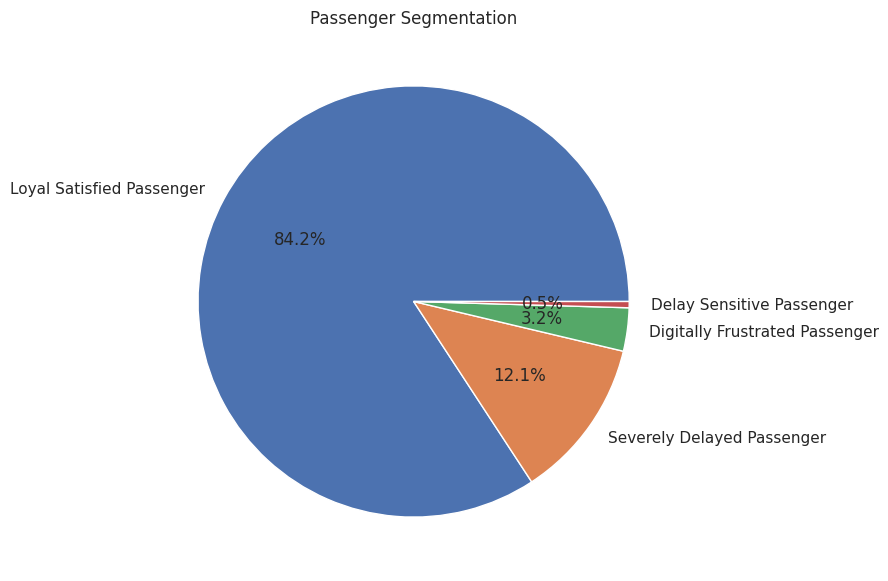

In [24]:
percent_cluster = (df_segm_pca['Segment'].value_counts(normalize=True)* 100)

plt.figure(figsize=(7,7))

plt.pie(
    percent_cluster.values,
    labels=percent_cluster.index,
    autopct='%1.1f%%'
)

plt.title('Passenger Segmentation')
plt.show()

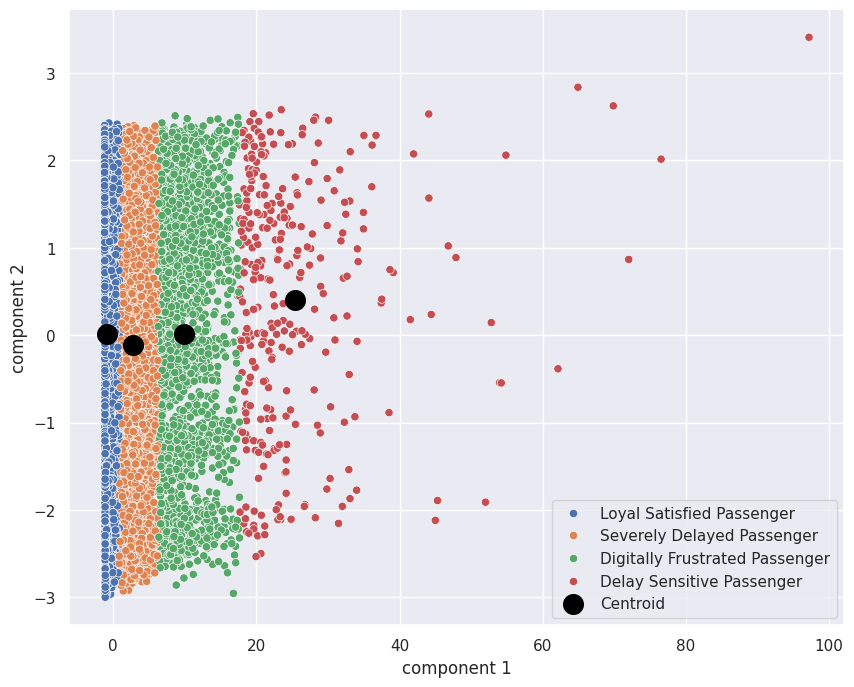

In [25]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='component 1',
    y='component 2',
    hue='Segment',
    data=df_segm_pca
)

centers = kmeans_pca.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    color='black',
    s=200,
    label='Centroid'
)

plt.legend()
plt.show()

#Hierarchy

In [26]:
import pandas as pd

pca_sample = pd.DataFrame(pca_scores).sample(
    n=2500,
    random_state=42
)

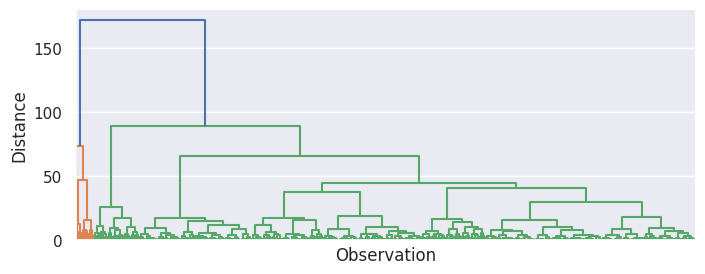

In [27]:
from scipy.cluster.hierarchy import linkage, dendrogram

h_cluster = linkage(pca_sample, method='ward')

plt.figure(figsize=(8,3))
plt.xlabel('Observation')
plt.ylabel('Distance')

dendrogram(
    h_cluster,
    show_leaf_counts=False,
    no_labels=True
)

plt.show()

In [28]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean',
    linkage='ward'
)

model.fit(pca_sample)

AgglomerativeClustering(n_clusters=4)

In [29]:
df_hc = pca_sample.copy()

df_hc['hc PCA'] = model.labels_

df_hc.head()

,0,1,2,3,hc PCA
55932,-1.181504,1.724768,0.584811,-1.650182,0
55084,-1.038028,0.039565,1.012712,0.211528,0
22238,-0.486946,-0.430700,-0.564225,0.509811,0
25422,-1.144870,-0.348731,0.175767,-0.254922,0
38242,-1.190438,1.826437,0.064539,0.107133,0


In [30]:
#cek distribusi data
pd.Series(model.labels_).value_counts()

,count
0,2243
2,181
1,72
3,4


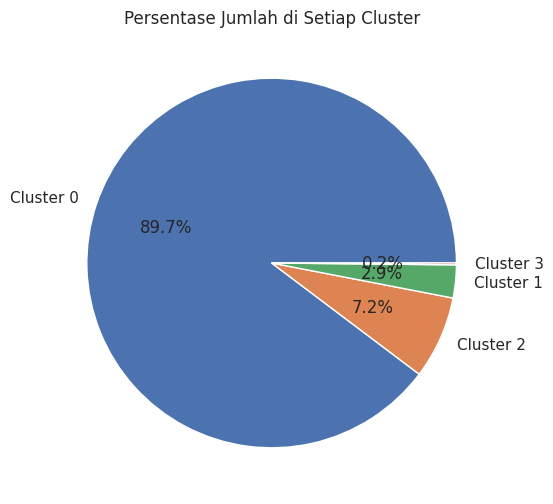

In [31]:
percent_clusters = (
    df_hc['hc PCA']
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(6,6))

plt.pie(
    percent_clusters.values,
    labels=[f'Cluster {i}' for i in percent_clusters.index],
    autopct='%1.1f%%'
)

plt.title('Persentase Jumlah di Setiap Cluster')
plt.show()

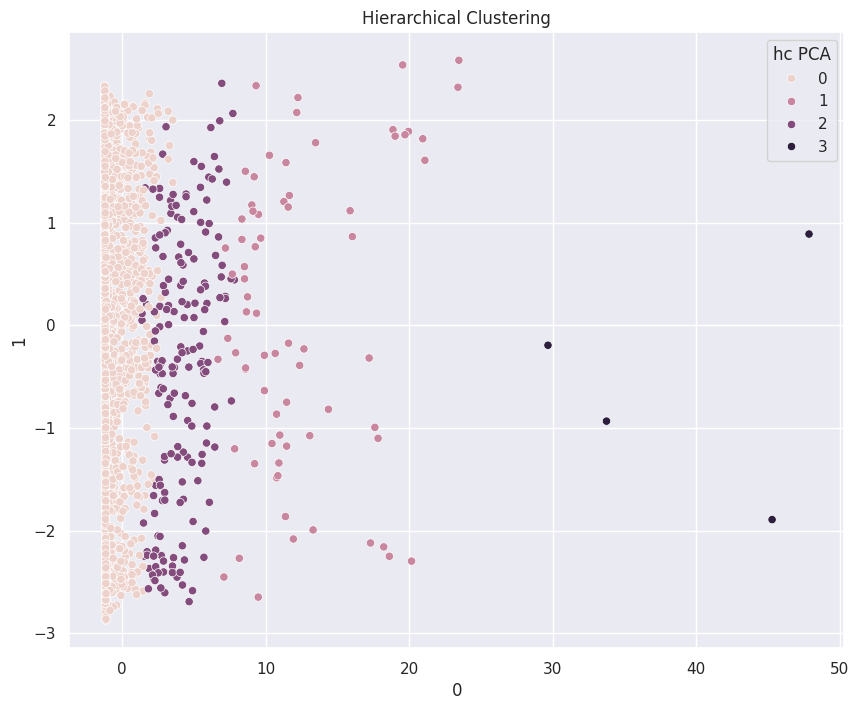

In [32]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_hc,
    x=0,
    y=1,
    hue='hc PCA'
)

plt.title('Hierarchical Clustering')
plt.show()

#DBSCAN

In [33]:
dbscan_data = pca_sample

In [34]:
db = DBSCAN(
    eps=2,
    min_samples=5
)

labels = db.fit_predict(pca_sample)

pd.Series(labels).value_counts().sort_index()

,count
-1,12
0,2477
1,5
2,6


In [35]:
for eps in [1,2,3,4,5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(pca_sample)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps}, clusters={n_clusters}, noise={n_noise}")

eps=1, clusters=4, noise=133
eps=2, clusters=3, noise=12
eps=3, clusters=1, noise=6
eps=4, clusters=1, noise=4
eps=5, clusters=1, noise=4


In [36]:
db = DBSCAN(
    eps=1,
    min_samples=5
)

labels = db.fit_predict(pca_sample)

pd.Series(labels).value_counts().sort_index()

,count
-1,133
0,2345
1,7
2,10
3,5


In [37]:
df_dbscan = pca_sample.copy()

df_dbscan['DBSCAN'] = labels

df_dbscan.head()

,0,1,2,3,DBSCAN
55932,-1.181504,1.724768,0.584811,-1.650182,0
55084,-1.038028,0.039565,1.012712,0.211528,0
22238,-0.486946,-0.430700,-0.564225,0.509811,0
25422,-1.144870,-0.348731,0.175767,-0.254922,0
38242,-1.190438,1.826437,0.064539,0.107133,0


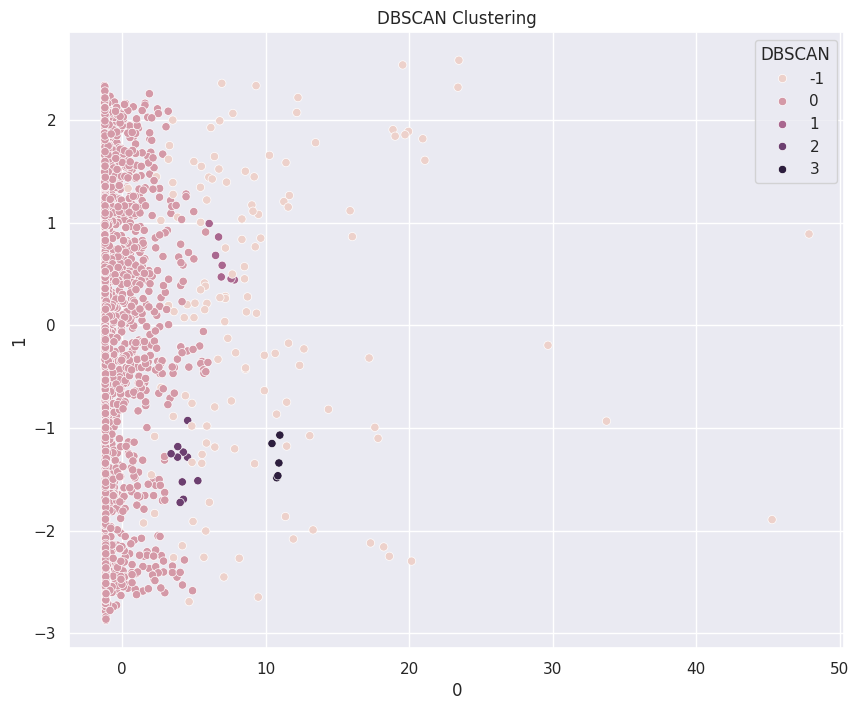

In [38]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_dbscan,
    x=0,
    y=1,
    hue='DBSCAN'
)

plt.title('DBSCAN Clustering')
plt.show()

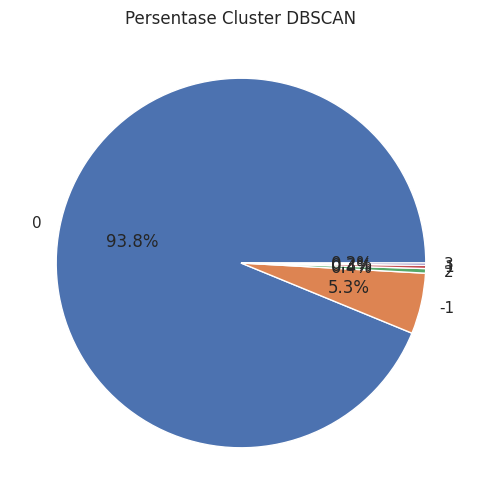

In [39]:
percent_cluster = (
    df_dbscan['DBSCAN']
    .value_counts(normalize=True)
    *100
)

plt.figure(figsize=(6,6))
plt.pie(
    percent_cluster.values,
    labels=percent_cluster.index,
    autopct='%1.1f%%'
)
plt.title('Persentase Cluster DBSCAN')
plt.show()

#Profiling

In [40]:
df_cluster = df_vif_clean.copy()

df_cluster['cluster'] = kmeans_pca.labels_

In [41]:
def highlight_max_min(s):
    is_max = s == s.max()
    is_min = s == s.min()

    return [
        'background-color:red' if v
        else 'background-color:lightgreen' if is_min[i]
        else ''
        for i, v in enumerate(is_max)
    ]

profil = (
    df_cluster
    .groupby('cluster')
    .mean(numeric_only=True)
    .round(2)
    .T
)

profil.style.apply(highlight_max_min, axis=1)

cluster,0,1,2,3
flight distance,1190.140000,1156.210000,1188.940000,1322.530000
food and drink,3.220000,3.120000,3.070000,3.080000
on-board service,3.410000,3.270000,3.250000,3.170000
leg room service,3.350000,3.260000,3.480000,3.630000
checkin service,3.330000,3.200000,3.200000,3.380000
arrival delay in minutes,3.450000,50.130000,143.900000,345.800000
avg digital score,3.010000,2.930000,2.950000,3.040000
class,1.040000,0.980000,1.010000,1.030000
gender_Male,0.490000,0.500000,0.490000,0.530000
customer type_Loyal Customer,0.820000,0.810000,0.820000,0.800000


#Evaluasi Perbandingan

In [42]:
# KMeans sample
kmeans_sample = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans_sample.fit(pca_sample)

KMeans(n_clusters=4, random_state=42)

In [43]:
hc_model = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean'
)

hc_model.fit(pca_sample)

AgglomerativeClustering(n_clusters=4)

In [44]:
db = DBSCAN(
    eps=1,
    min_samples=5
)

dbscan_labels = db.fit_predict(pca_sample)

In [45]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

def create_comparison_table(data, kmeans_model, hierarchical_model, dbscan_labels):

    # KMeans
    kmeans_silhouette = silhouette_score(data, kmeans_model.labels_)
    kmeans_ch = calinski_harabasz_score(data, kmeans_model.labels_)
    kmeans_db = davies_bouldin_score(data, kmeans_model.labels_)

    # Hierarchical
    hierarchical_silhouette = silhouette_score(data, hierarchical_model.labels_)
    hierarchical_ch = calinski_harabasz_score(data, hierarchical_model.labels_)
    hierarchical_db = davies_bouldin_score(data, hierarchical_model.labels_)

    # DBSCAN
    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        data[mask],
        dbscan_labels[mask]
    )

    dbscan_ch = calinski_harabasz_score(
        data[mask],
        dbscan_labels[mask]
    )

    dbscan_db = davies_bouldin_score(
        data[mask],
        dbscan_labels[mask]
    )

    comparison_table = pd.DataFrame({
        'Metric': [
            'Silhouette Score',
            'Calinski-Harabasz Index',
            'Davies-Bouldin Index'
        ],
        'KMeans': [
            kmeans_silhouette,
            kmeans_ch,
            kmeans_db
        ],
        'Hierarchical': [
            hierarchical_silhouette,
            hierarchical_ch,
            hierarchical_db
        ],
        'DBSCAN': [
            dbscan_silhouette,
            dbscan_ch,
            dbscan_db
        ]
    })

    return comparison_table

In [46]:
comparison_table = create_comparison_table(
    pca_sample,
    kmeans_sample,
    hc_model,
    dbscan_labels
)

comparison_table

,Metric,KMeans,Hierarchical,DBSCAN
0,Silhouette Score,0.299767,0.511358,0.472577
1,Calinski-Harabasz Index,1935.845489,1603.053997,99.179145
2,Davies-Bouldin Index,0.984251,0.712021,0.474661


In [47]:
def create_comparison_table(data, kmeans_model, hierarchical_model, dbscan_labels):

    # K-Means
    kmeans_silhouette = silhouette_score(data, kmeans_model.labels_, metric='manhattan')
    kmeans_ch = calinski_harabasz_score(data, kmeans_model.labels_)
    kmeans_db = davies_bouldin_score(data, kmeans_model.labels_)

    # Hierarchical
    hierarchical_silhouette = silhouette_score(data, hierarchical_model.labels_, metric='manhattan')
    hierarchical_ch = calinski_harabasz_score(data, hierarchical_model.labels_)
    hierarchical_db = davies_bouldin_score(data, hierarchical_model.labels_)

    # DBSCAN (exclude noise)
    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        data[mask],
        dbscan_labels[mask],
        metric='manhattan'
    )

    dbscan_ch = calinski_harabasz_score(
        data[mask],
        dbscan_labels[mask]
    )

    dbscan_db = davies_bouldin_score(
        data[mask],
        dbscan_labels[mask]
    )

    comparison_table = pd.DataFrame({
        'Metric': [
            'Silhouette Score',
            'Calinski-Harabasz Index',
            'Davies-Bouldin Index'
        ],
        'K-Means Clustering': [
            kmeans_silhouette,
            kmeans_ch,
            kmeans_db
        ],
        'Hierarchical Clustering': [
            hierarchical_silhouette,
            hierarchical_ch,
            hierarchical_db
        ],
        'DBSCAN': [
            dbscan_silhouette,
            dbscan_ch,
            dbscan_db
        ]
    })

    return comparison_table

In [48]:
# model = AgglomerativeClustering(
#     n_clusters=2,
#     metric='euclidean',
#     linkage='ward'
# )

# labels = model.fit_predict(pca_sample)

In [49]:
# from sklearn.cluster import AgglomerativeClustering

# model = AgglomerativeClustering(n_clusters=2, metric='euclidean') # 2 dari number of hierrarchy siku
# model.fit(pca_scores)